In [147]:
!pip install wfdb

#LABORATORIO 2: Uso de señales de physionet

###**Señal 1**

In [148]:
import wfdb

#European ST-T Database

record = wfdb.rdrecord('e0103', pn_dir='edb')
# Read a WFDB anno tation file record_name.extension and return an Annotation
#annotation contiene las anotaciones importantes de la data que se ve en el siguiente codigo

annotation = wfdb.rdann('e0103', 'atr', pn_dir='edb')

# Tipo: numpy array
# Forma: (N, canales)
signal = record.p_signal
fs = record.fs

In [149]:
annotation.sample, annotation.symbol, annotation.aux_note;

In [150]:
signal, signal.shape

(array([[0.455, 3.755],
        [0.46 , 3.78 ],
        [0.45 , 3.765],
        ...,
        [0.535, 3.91 ],
        [0.54 , 3.87 ],
        [0.53 , 3.865]]),
 (1800000, 2))

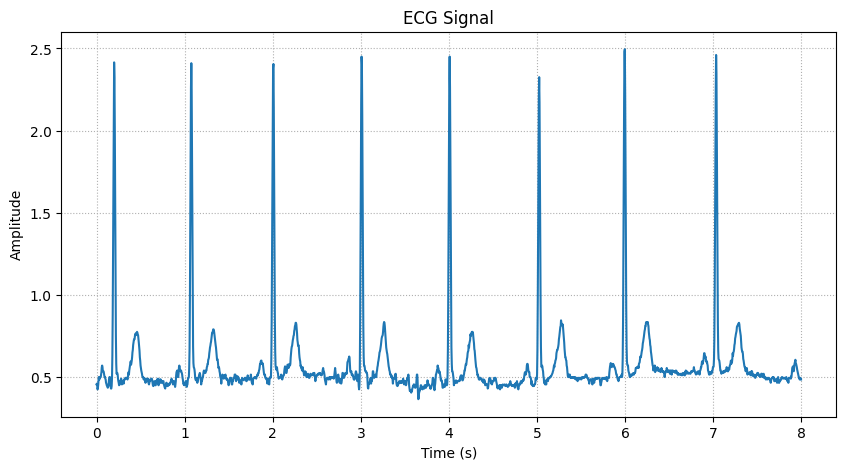

In [151]:
import matplotlib.pyplot as plt
import numpy as np

N = signal.shape[0] #da el primer valor de la tupla, osea la cantidad de muestra
n = np.arange(N)
t = n/fs

plt.figure(figsize=(10,5))
plt.plot(t[:2000], signal[:2000,0]) #0 puede ser 1, tomariamos del segundo canal
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

(array([5.67882260e-01, 2.84375156e-01, 7.93520746e-04, ...,
        7.44656934e-06, 2.47440103e-04, 4.95887162e-04]),
 array([0.00000000e+00, 1.38888889e-04, 2.77777778e-04, ...,
        1.24999722e+02, 1.24999861e+02, 1.25000000e+02]),
 <matplotlib.lines.Line2D at 0x79fa88c3e0f0>)

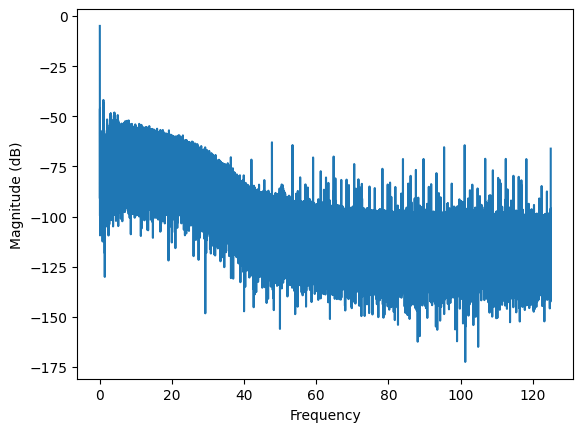

In [152]:
x = signal[:,0]

plt.magnitude_spectrum(x, Fs=fs, scale='dB')

(array([4.74946500e-04, 1.27628085e-03, 7.93420901e-04, ...,
        7.44656934e-06, 2.47440103e-04, 4.95887162e-04]),
 array([0.00000000e+00, 1.38888889e-04, 2.77777778e-04, ...,
        1.24999722e+02, 1.24999861e+02, 1.25000000e+02]),
 <matplotlib.lines.Line2D at 0x79fa88bcf6e0>)

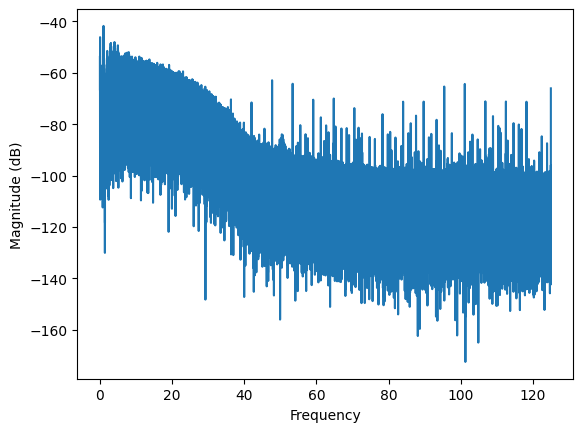

In [153]:
x_dc_removed = x - np.mean(x)

plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')

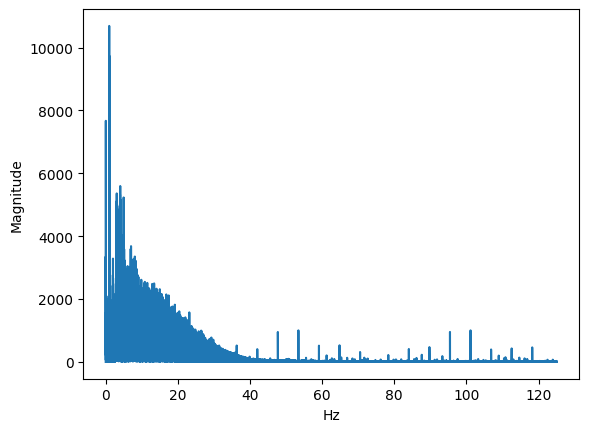

In [154]:
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

plt.plot(freqs[:len(x_dc_removed)//2], np.abs(X[:len(x_dc_removed)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

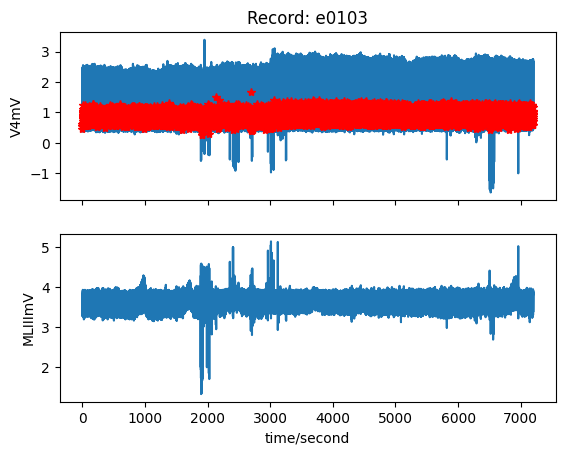

In [155]:
wfdb.plot_wfdb(record=record, annotation=annotation)

####**Filtro pasa banda - señal 1**

In [156]:
from scipy.signal import butter, filtfilt

def bandpass(signal, fs, low=0.5, high=40):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass(signal[:,0], fs)

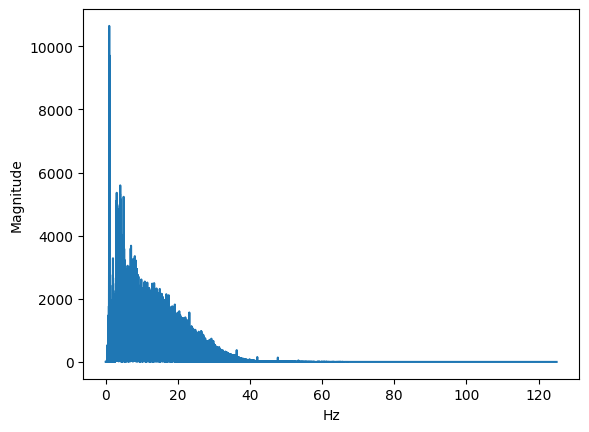

In [157]:
X = np.fft.fft(filtered)
freqs = np.fft.fftfreq(len(filtered), 1/fs)

plt.plot(freqs[:len(filtered)//2], np.abs(X[:len(filtered)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

####**Segmentación (ventanas) - señal1**

In [158]:
window_size = int(2 * fs)  #cada ventana será de 2 segundos
#el numero de segundos se determina dependiendo del ritmo cardiaco que queremos ver
segments = []

for i in range(0, len(filtered)-window_size, window_size):
    segments.append(filtered[i:i+window_size])

####**Feature extraction - señal1**

In [159]:
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment)
    ]

In [160]:
extract_features(segments[0])

[np.float64(-0.0008960827011906006),
 np.float64(0.2622768915698183),
 np.float64(1.8359011418564646)]

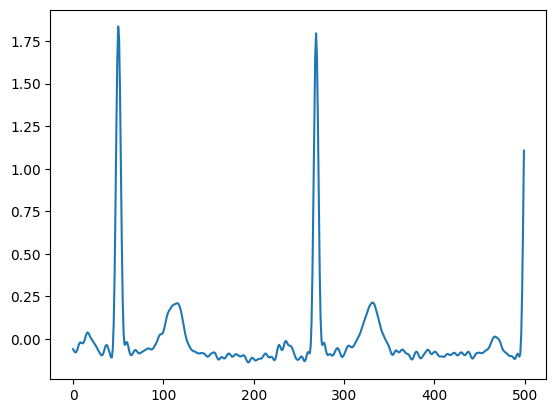

In [161]:
plt.plot(segments[0]) #se ve la figura de la primera ventana

###**Señal 2**

In [162]:
record = wfdb.rdrecord('301', pn_dir='stdb')

#annotation contiene las anotaciones importantes de la data que se ve en el siguiente codigo
annotation = wfdb.rdann('301', 'atr', pn_dir='stdb')

# Tipo: numpy array
# Forma: (N, canales)
signal = record.p_signal
fs = record.fs

In [163]:
annotation.sample, annotation.symbol, annotation.aux_note;

In [164]:
signal, signal.shape

(array([[-0.28135593, -0.04666667],
        [-0.28135593, -0.03      ],
        [-0.26779661, -0.02333333],
        ...,
        [-0.15932203, -0.21333333],
        [-0.16271186, -0.2       ],
        [-0.15254237, -0.19      ]]),
 (700426, 2))

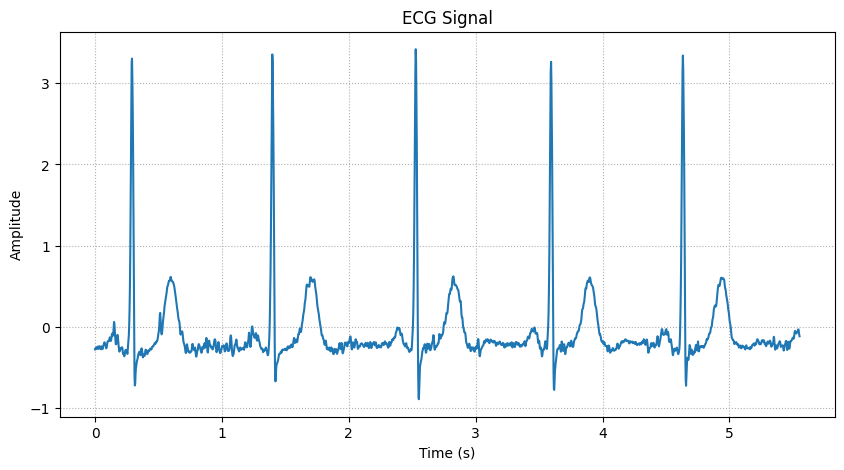

In [165]:
import matplotlib.pyplot as plt
import numpy as np

N = signal.shape[0] #da el primer valor de la tupla, osea la cantidad de muestra
n = np.arange(N)
t = n/fs

plt.figure(figsize=(10,5))
plt.plot(t[:2000], signal[:2000,0]) #0 puede ser 1, tomariamos del segundo canal
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

(array([8.25006972e-02, 4.12216457e-02, 1.97909650e-05, ...,
        3.11907201e-05, 1.76693255e-04, 2.93579784e-04]),
 array([0.00000000e+00, 5.13972925e-04, 1.02794585e-03, ...,
        1.79998972e+02, 1.79999486e+02, 1.80000000e+02]),
 <matplotlib.lines.Line2D at 0x79fa8876d2e0>)

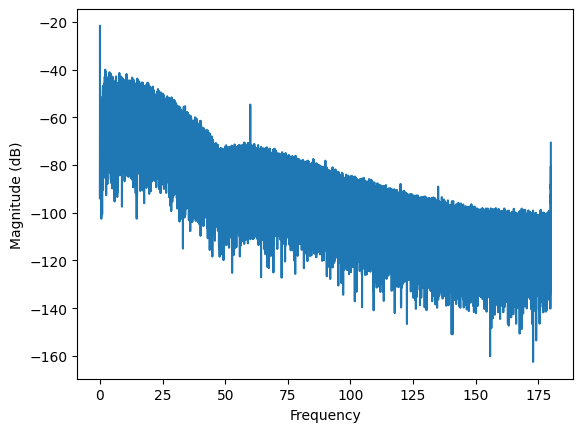

In [166]:
x = signal[:,0]

plt.magnitude_spectrum(x, Fs=fs, scale='dB')

(array([3.18789824e-04, 2.95837361e-04, 1.97594009e-05, ...,
        3.11907201e-05, 1.76693255e-04, 2.93579784e-04]),
 array([0.00000000e+00, 5.13972925e-04, 1.02794585e-03, ...,
        1.79998972e+02, 1.79999486e+02, 1.80000000e+02]),
 <matplotlib.lines.Line2D at 0x79fa88790b00>)

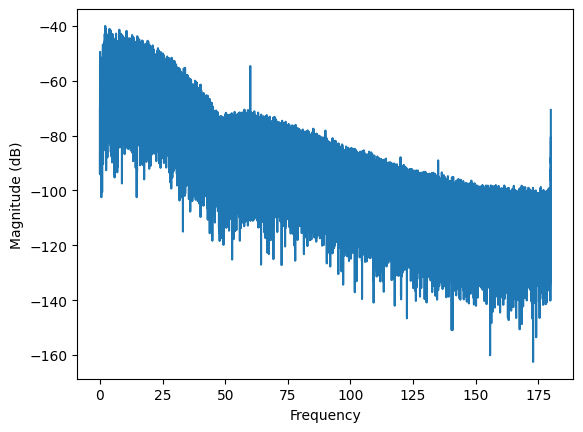

In [167]:
x_dc_removed = x - np.mean(x)

plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')

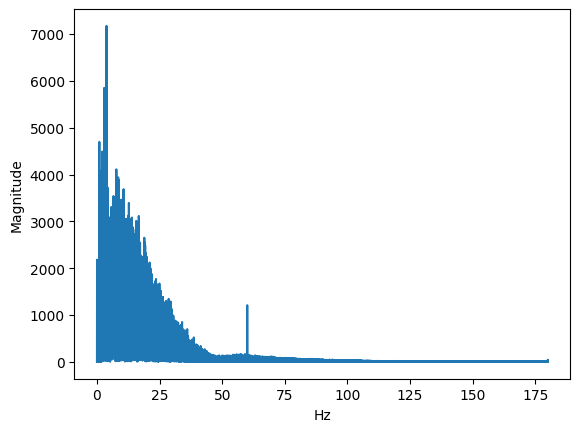

In [168]:
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

plt.plot(freqs[:len(x_dc_removed)//2], np.abs(X[:len(x_dc_removed)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

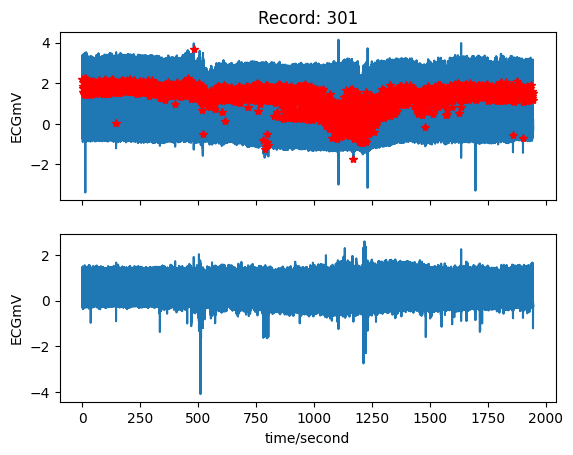

In [169]:
wfdb.plot_wfdb(record=record, annotation=annotation)

####**Filtro pasa banda-Señal2**

In [170]:
from scipy.signal import butter, filtfilt

def bandpass(signal, fs, low=0.5, high=40):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass(signal[:,0], fs)

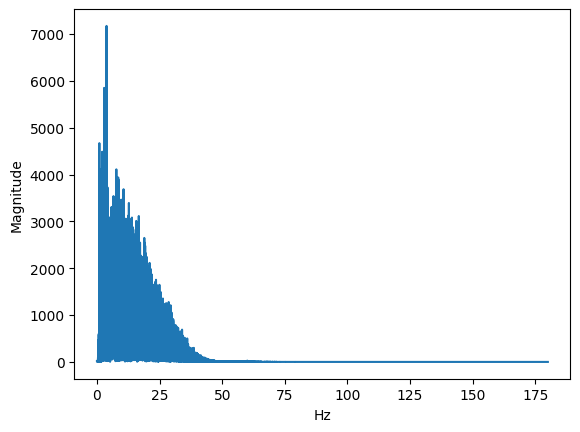

In [171]:
X = np.fft.fft(filtered)
freqs = np.fft.fftfreq(len(filtered), 1/fs)

plt.plot(freqs[:len(filtered)//2], np.abs(X[:len(filtered)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

####**Segmentación - Señal 2**

In [172]:
window_size = int(2 * fs)  #cada ventana será de 2 segundos
#el numero de segundos se determina dependiendo del ritmo cardiaco que queremos ver
segments = []

for i in range(0, len(filtered)-window_size, window_size):
    segments.append(filtered[i:i+window_size])

####**Feature extraction - Señal 2**

In [173]:
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment)
    ]

In [174]:
extract_features(segments[0])

[np.float64(0.02173086892656665),
 np.float64(0.4911656038191767),
 np.float64(3.3961949134630243)]

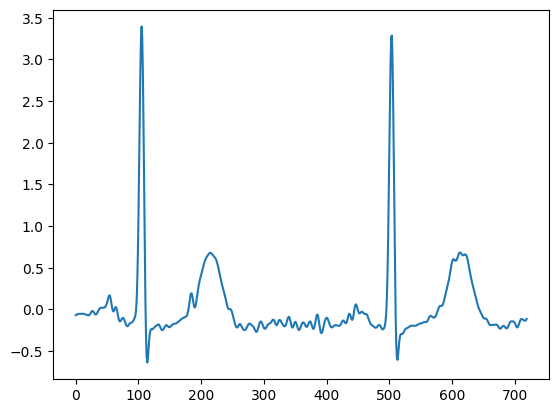

In [175]:
plt.plot(segments[0]) #se ve la figura de la primera ventana

###**Señal 3**

In [176]:
record = wfdb.rdrecord('800', pn_dir='svdb')

annotation = wfdb.rdann('800', 'atr', pn_dir='svdb')

# Tipo: numpy array
# Forma: (N, canales)
signal = record.p_signal
fs = record.fs

In [177]:
annotation.sample,annotation.symbol, annotation.aux_note;

In [178]:
signal, signal.shape

(array([[-0.505,  0.615],
        [-0.495,  0.755],
        [-0.545,  0.805],
        ...,
        [-0.055, -0.165],
        [-0.075, -0.165],
        [-0.085, -0.135]]),
 (230400, 2))

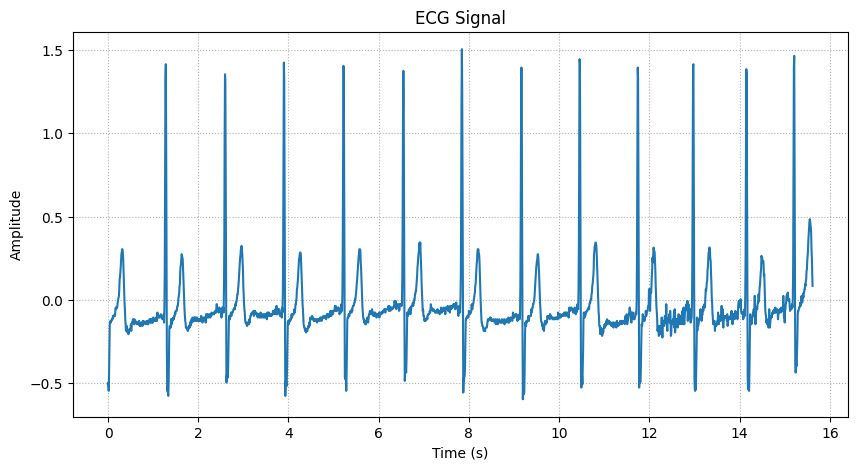

In [179]:
import matplotlib.pyplot as plt
import numpy as np

N = signal.shape[0] #da el primer valor de la tupla, osea la cantidad de muestra
n = np.arange(N)
t = n/fs

plt.figure(figsize=(10,5))
plt.plot(t[:2000], signal[:2000,0]) #0 puede ser 1, tomariamos del segundo canal
plt.title("ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(ls=":")
plt.show()

(array([3.72825925e-02, 1.85383659e-02, 5.98795657e-04, ...,
        5.49888319e-05, 1.26544941e-04, 1.64892183e-04]),
 array([0.00000000e+00, 5.55555556e-04, 1.11111111e-03, ...,
        6.39988889e+01, 6.39994444e+01, 6.40000000e+01]),
 <matplotlib.lines.Line2D at 0x79fa8859d2b0>)

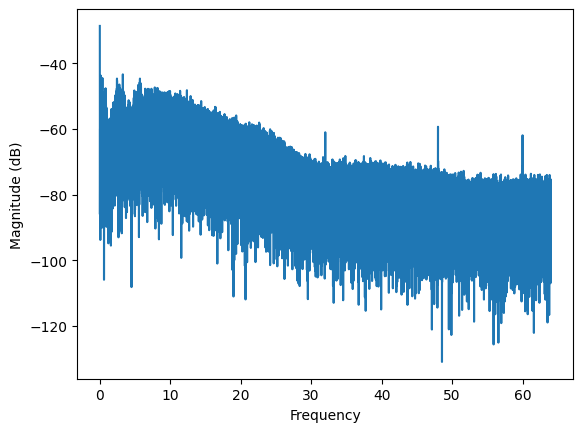

In [180]:
x = signal[:,0]

plt.magnitude_spectrum(x, Fs=fs, scale='dB')

(array([2.41691363e-04, 2.55859813e-04, 5.98780824e-04, ...,
        5.49888319e-05, 1.26544941e-04, 1.64892183e-04]),
 array([0.00000000e+00, 5.55555556e-04, 1.11111111e-03, ...,
        6.39988889e+01, 6.39994444e+01, 6.40000000e+01]),
 <matplotlib.lines.Line2D at 0x79fa886465d0>)

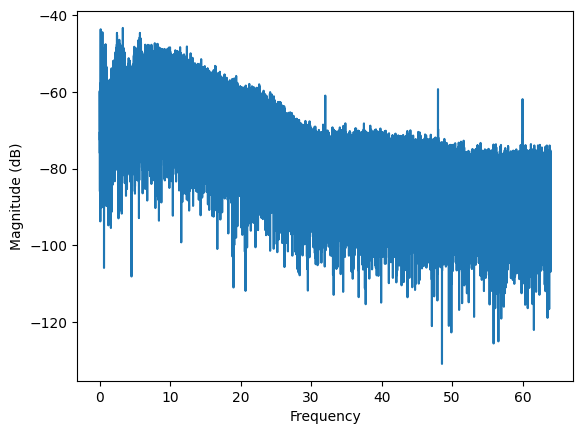

In [181]:
x_dc_removed = x - np.mean(x)

plt.magnitude_spectrum(x_dc_removed, Fs=fs, scale='dB')

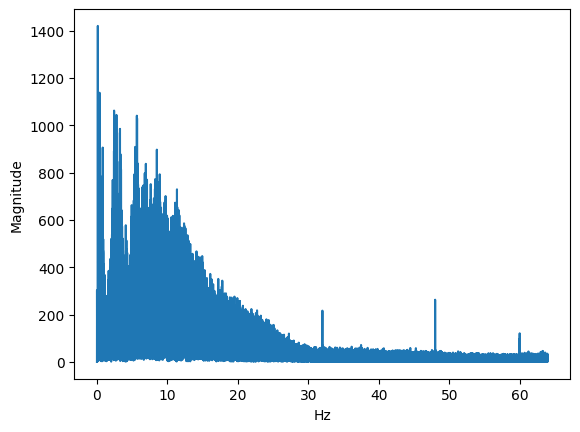

In [182]:
X = np.fft.fft(x_dc_removed)
freqs = np.fft.fftfreq(len(x_dc_removed), 1/fs)

plt.plot(freqs[:len(x_dc_removed)//2], np.abs(X[:len(x_dc_removed)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

In [183]:
print("Número de señales:", record.n_sig)
print("Forma de la señal:", record.p_signal.shape)
print("Nombres de las señales:", record.sig_name)

Número de señales: 2
Forma de la señal: (230400, 2)
Nombres de las señales: ['ECG1', 'ECG2']


In [184]:
from wfdb.plot import plot_items

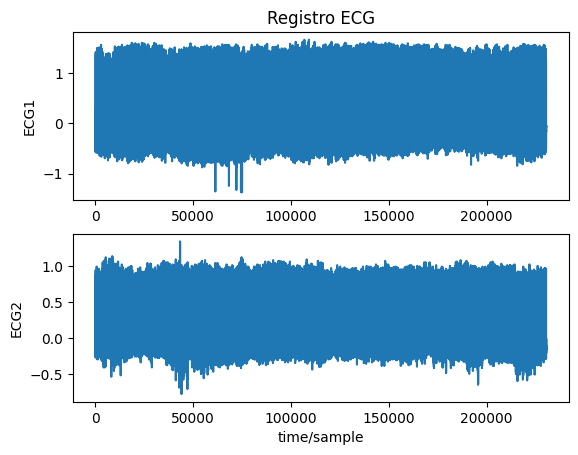

In [185]:
wfdb.plot.plot_items(
    signal=record.p_signal,
    fs=record.fs,
    sig_name=['ECG1', 'ECG2'],
    ylabel=['ECG1', 'ECG2'],
    title='Registro ECG'
)

####**Filtro - señal 3**

In [186]:
from scipy.signal import butter, filtfilt

def bandpass(signal, fs, low=0.5, high=40):
    b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass(signal[:,0], fs)

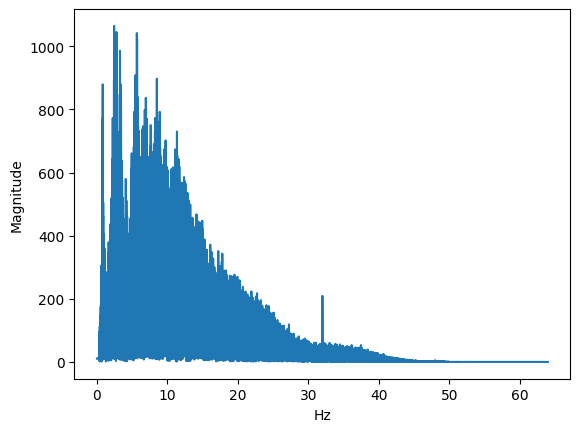

In [187]:
X = np.fft.fft(filtered)
freqs = np.fft.fftfreq(len(filtered), 1/fs)

plt.plot(freqs[:len(filtered)//2], np.abs(X[:len(filtered)//2]))
plt.xlabel("Hz")
plt.ylabel("Magnitude")
plt.show()

####**Segmentación (ventanas) - señal 3**

In [188]:
window_size = int(2 * fs)  #cada ventana será de 2 segundos
#el numero de segundos se determina dependiendo del ritmo cardiaco que queremos ver
segments = []

for i in range(0, len(filtered)-window_size, window_size):
    segments.append(filtered[i:i+window_size])

####**Feature extraction - señal 3**

In [189]:
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment)
    ]

In [190]:
extract_features(segments[0])

[np.float64(0.04031465703498741),
 np.float64(0.23722243506180585),
 np.float64(1.4574601849943625)]

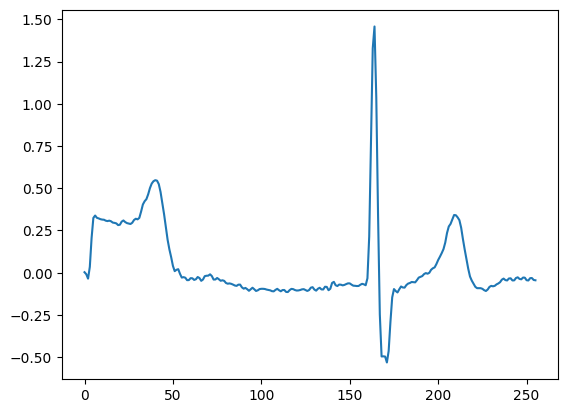

In [191]:
plt.plot(segments[0]) #se ve la figura de la primera ventana